# Archetype clustering experimentation: PCA + KMeans (historical)

This notebook keeps our **exploratory KMeans** work: same preprocessing and feature rules as production, but clustering with KMeans only.

**Production** archetype clustering uses **Gaussian mixture models (GMM)** after PCA—see `clustering_gmm_experimentation.ipynb` and `fit_archetype_clustering` / the gold archetype clustering CLI stage.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.ml.archetype_clustering import (
    ArchetypeClusteringConfig,
    numeric_feature_columns,
    prepare_dataframe_for_archetype_clustering,
)
from src.ml.archetype_finetune import (
    grid_sweep_pca_and_k,
    pca_cumulative_variance,
    scaled_feature_matrix
)
from src.pipeline.lake_paths import gold_player_year_output_key
from src.pipeline.s3_parquet import read_parquet_from_s3

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

# Data Loading

In [2]:
ROLE = "pitcher"
YEAR = 2025

S3_BUCKET = "diamond-dna"
GOLD_PREFIX = "gold/statcast"

LOCAL_GOLD_PARQUET: Path | None = None  # e.g. Path(r"C:\\data\\player_year_features_preprocessed.parquet")

RANDOM_STATE = 42
N_INIT = 10

In [3]:
def load_gold_player_year(
    *,
    role: str,
    year: int,
    bucket: str,
    gold_prefix: str,
    local_parquet: Path | None,
) -> pd.DataFrame:
    if local_parquet is not None and local_parquet.is_file():
        df = pd.read_parquet(local_parquet)
    else:
        key = gold_player_year_output_key(gold_prefix, role, year)
        df = read_parquet_from_s3(bucket, key, missing_key_log="warning")
        if df is None:
            raise FileNotFoundError(f"No gold parquet at s3://{bucket}/{key}")
    if "role" not in df.columns:
        df = df.copy()
        df["role"] = role
    return df


gold_df = load_gold_player_year(
    role=ROLE,
    year=YEAR,
    bucket=S3_BUCKET,
    gold_prefix=GOLD_PREFIX,
    local_parquet=LOCAL_GOLD_PARQUET,
)
gold_df.shape

(494, 121)

# Columns used for PCA / clustering features (same as production GMM path)

In [4]:
df_idx = prepare_dataframe_for_archetype_clustering(gold_df)
feat_cols = numeric_feature_columns(df_idx)
print(f"n_features = {len(feat_cols)}")
feat_cols

n_features = 30


['batter_chase_rate',
 'batter_contact_rate',
 'batter_swing_rate',
 'batter_whiff_rate',
 'batter_zone_swing_rate',
 'delta_run_exp_mean',
 'edge_percent',
 'fastball_velo_mean',
 'fb_percent_allowed',
 'first_pitch_strike_rate',
 'gb_percent_allowed',
 'iffb_percent_allowed',
 'in_zone_rate',
 'ld_percent_allowed',
 'offspeed_velo_mean',
 'pfx_x_iqr',
 'pfx_z_iqr',
 'pfx_z_mean',
 'pitch_type_entropy',
 'plate_x_mean',
 'plate_x_sd',
 'plate_z_mean',
 'plate_z_sd',
 'platoon_xwoba_allowed_diff',
 'release_extension_iqr',
 'release_extension_mean',
 'release_speed_iqr',
 'release_speed_max',
 'release_spin_rate_iqr',
 'velo_differential']

## 1) Cumulative PCA variance

Uses **`pca_cumulative_variance`** from `archetype_finetune` on **`scaled_feature_matrix`** output.

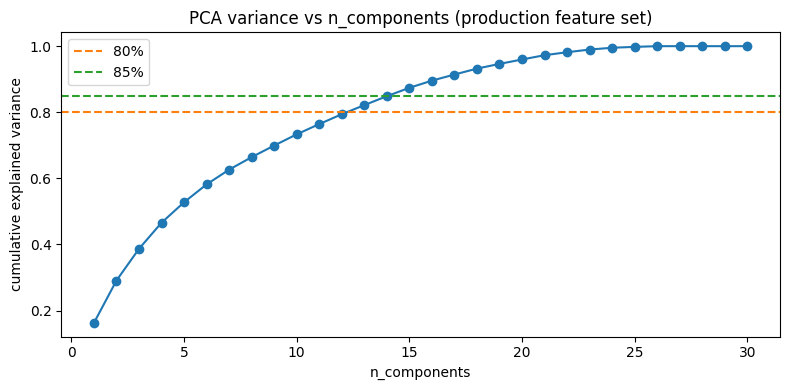

In [5]:
X_scaled, _cols_used, _scaler = scaled_feature_matrix(gold_df)
assert _cols_used == feat_cols

MAX_PC_PROBE = 50
cum, ratios = pca_cumulative_variance(
    X_scaled, max_components=MAX_PC_PROBE, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, "o-")
ax.axhline(0.80, color="C1", ls="--", label="80%")
ax.axhline(0.85, color="C2", ls="--", label="85%")
ax.set_xlabel("n_components")
ax.set_ylabel("cumulative explained variance")
ax.legend()
ax.set_title("PCA variance vs n_components (production feature set)")
plt.tight_layout()
plt.show()

## 2) Grid sweep over PCA size and K

Uses **`grid_sweep_pca_and_k`** from `archetype_finetune`.

In [6]:
PCA_N_COMPONENTS_CANDIDATES = [6, 8, 10, 12, 16, 20, 24]
K_MIN = 4
K_MAX = 9

grid = grid_sweep_pca_and_k(
    X_scaled,
    pca_n_components_list=PCA_N_COMPONENTS_CANDIDATES,
    k_min=K_MIN,
    k_max=K_MAX,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)

grid.sort_values("silhouette", ascending=False).head(25)

,pca_n_components,pca_total_explained_variance,k,inertia,silhouette,davies_bouldin
0,6,0.581742,4,5671.836025,0.151171,1.762473
1,6,0.581742,5,5255.379864,0.139051,1.754073
3,6,0.581742,7,4701.863204,0.138518,1.654195
4,6,0.581742,8,4519.835134,0.136859,1.641034
2,6,0.581742,6,4958.199412,0.135115,1.764302
5,6,0.581742,9,4348.480686,0.132873,1.638688
6,8,0.664160,4,6881.060364,0.127325,1.963436
7,8,0.664160,5,6454.411852,0.115256,1.949972
12,10,0.733204,4,7909.167844,0.115022,2.067209
9,8,0.664160,7,5893.956100,0.114134,1.926347


In [7]:
pick = grid.sort_values("silhouette", ascending=False).iloc[0]
PCA_N = int(pick["pca_n_components"])
K = int(pick["k"])
print("Suggested (max silhouette in grid): PCA_N =", PCA_N, ", K =", K)

# Override by hand after inspection:
# PCA_N = 12
# K = 7

prod_cfg = ArchetypeClusteringConfig(
    pca_n_components=PCA_N,
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
prod_cfg

Suggested (max silhouette in grid): PCA_N = 6 , K = 4


ArchetypeClusteringConfig(pca_n_components=6, n_clusters=4, random_state=42, n_init=10)

# 3) Final thoughts on the PCA + KMeans path

KMeans did not give convincing separation for this data (e.g. weak silhouette). **Production** has moved to **Gaussian mixture models** after PCA; see `clustering_gmm_experimentation.ipynb`.

The `ArchetypeClusteringConfig` below mirrors hyperparameters you might pass to the pipeline (`pca_n_components`, `n_clusters` as GMM `n_components`, optional `covariance_type`); this notebook only uses it as a typed record—the grid above is KMeans-only.